# Simulations used in lecturenote

This file gives the output for the simulation used in the lecturenote. First we import functions and libraries:

In [46]:
%load_ext rpy2.ipython
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import importlib
sys.path.append(os.path.abspath(".."))

# Import functions
from functions import simulation_master_v1
from functions import bubble_simulation

# Reload functions
importlib.reload(simulation_master_v1)
importlib.reload(bubble_simulation)

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


<module 'functions.bubble_simulation' from '/Users/emilrand/Desktop/ku/Bachelor/6. semester/ba/ba_repo/functions/bubble_simulation.py'>

Now we plot a simple AR(1) with a unit root / random walk:

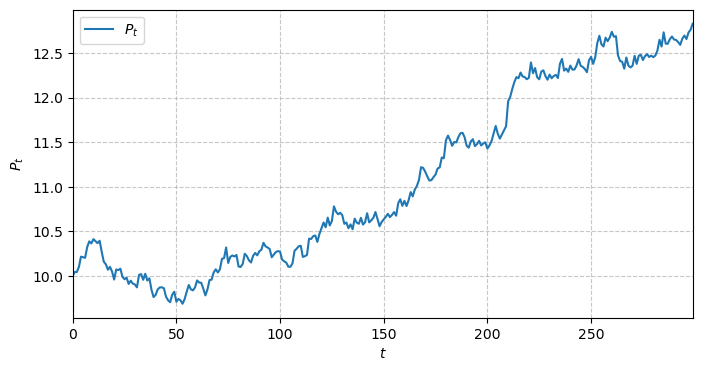

In [5]:
Pf, B, P_rw = simulation_master_v1.simulate_price_with_bubbles(
    T=300,
    rho=1.0,
    sigma_f=0.07,
    mu_f=0.01,
    P0=10.0,
    include_bubble=False,  # pure AR(1) random walk with drift
    seed=42,
)

plt.figure(figsize=(8, 4))
plt.plot(P_rw.index, P_rw.values, label="$P_t$")
plt.xlabel("$t$")
plt.ylabel("$P_t$")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.margins(x=0)

# save as pdf to figures folder
plt.savefig("../figures/P_rw.pdf", format="pdf", bbox_inches="tight")
plt.show()


P_rw.to_csv("../data/P_rw.csv", index=False)

Taking the above series from P_rw.csv, and test it with the exuber package yields following results, which means we do not reject $H_0$, as we would expect, since this is indeed a random walk $\rho = 1$. 

And the BSADF looks like this

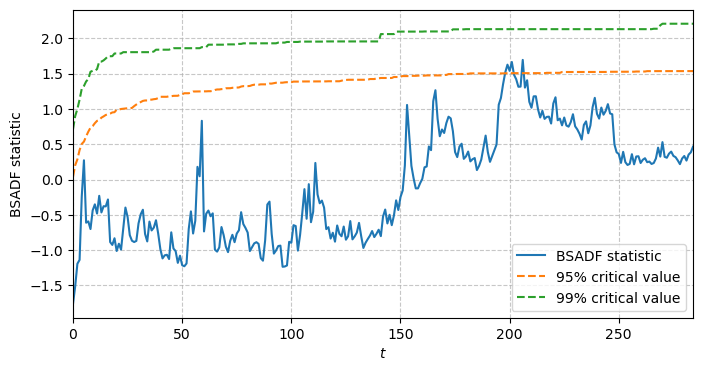

In [7]:
# Load BSADF statistic and critical values for P_rw
P_rw_bsadf_stat = pd.read_csv("../data/simulated/bsadf/P_rw_bsadf_stat.csv")   # column: "bsadf"
P_rw_bsadf_cv   = pd.read_csv("../data/simulated/bsadf/P_rw_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

t = np.arange(len(P_rw_bsadf_stat))  # time index

plt.figure(figsize=(8, 4))
plt.plot(t, P_rw_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_rw_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_rw_bsadf_cv["99%"], "--", label="99% critical value")

plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)

# save as pdf to figures folder
plt.savefig("../figures/P_rw_bsadf.pdf", format="pdf", bbox_inches="tight")
plt.show()

Now we introduce a single bubble to the series, so $P_t$ will look like this

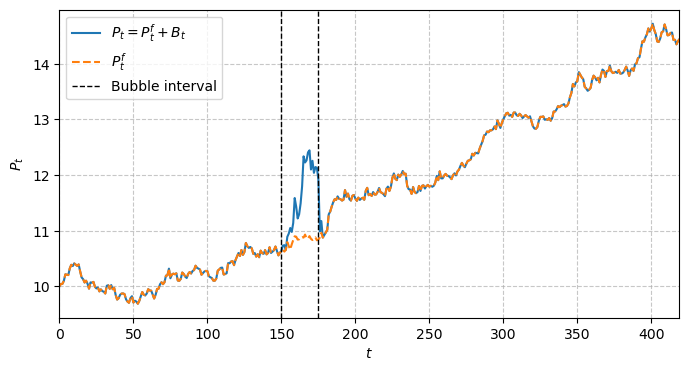

In [47]:
Pf, B, P = simulation_master_v1.simulate_price_with_bubbles(
    T=420,
    P0=10.0,
    sigma_f=0.07,
    mu_f=0.01,
    rho=1.0,              # random walk fundamental
    include_bubble=True,
    R=0.005,
    sigma_b=0.20,
    bubble_decay=0.00,
    t_start1=150,          # first bubble interval
    t_end1=175,
    B0_1=0.00,
    seed=42,
    eta=1,
)

plt.figure(figsize=(8, 4))
plt.plot(P, label=r"$P_t = P_t^f + B_t$")
plt.plot(Pf, label=r"$P_t^f$", linestyle="--")
# plt.plot(B, label=r"$B_t$")
plt.xlabel("$t$")
plt.axvline(150, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(175, color="black", linestyle="--", linewidth=1)
plt.ylabel("$P_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.legend()
# save as pdf to figures folder
plt.savefig("../figures/P_rw_bubble.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Save price series as csv to data folder
P.to_csv("P_rw_bubble.csv", index=False)

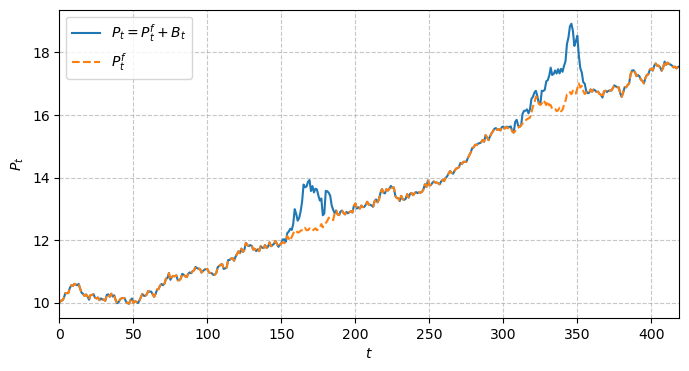

In [44]:
Pf, B, P = simulation_master_v1.simulate_price_with_bubbles(
    T=420,
    P0=10.0,
    sigma_f= T**(-0.4),
    mu_f=0.02,
    rho=1.0,              # random walk fundamental
    include_bubble=True,
    R=0.005,
    sigma_b=0.20,
    bubble_decay=0.70,
    t_start1=150,          # first bubble interval
    t_end1=175,
    B0_1=0.01,
    seed=42,
    eta=1,
    t_start2=300,
    t_end2=350,
    B0_2=0.01,
)

plt.figure(figsize=(8, 4))
plt.plot(P, label=r"$P_t = P_t^f + B_t$")
plt.plot(Pf, label=r"$P_t^f$", linestyle="--")
# plt.plot(B, label=r"$B_t$")
plt.xlabel("$t$")
plt.ylabel("$P_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.legend()
# save as pdf to figures folder
plt.show()

The results are given below. We do not reject with ADF on whole sample. But we reject with SADF and GSADF.

In [17]:
%%R
library(exuber)

# 1. Load series
dat <- read.csv('P_rw_bubble.csv') 
y   <- ts(dat$Price)     # change after $ to the column name
T   <- length(y)

# 2. Test statistics (ADF, SADF, GSADF)
res  <- radf(y, lag = 0)

# 3. Critical values (Monte Carlo)
cv   <- radf_mc_cv(n = T, nrep = 2000, seed = 123)

options(digits = 10)
print(res)
print(cv)

# BSADF critical values (90%, 95%, 99%) and test statistic
cv$bsadf_cv # cv
res$bsadf   # test statistic

# download BSADF data

# BSADF test statistic over time
bsadf_stat <- data.frame(bsadf = as.numeric(res$bsadf))
write.csv(bsadf_stat, "P_rw_bubble_bsadf.csv", row.names = FALSE)

# BSADF critical values (90, 95, 99)
bsadf_cv <- as.data.frame(cv$bsadf_cv)        # keep all significance-level columns
write.csv(bsadf_cv, "P_rw_bubble_cv.csv", row.names = FALSE)




── radf (minw = 34, lag = 0) ───────────────────────────────────────────────────

       id         adf     sadf     gsadf
  series1  -0.7447355  3.88175  3.924058

  gsadf_panel
     3.924058


── Monte Carlo (minw = 34, nrep = 2000) ────────────────────────────────────────

  sig          adf      sadf     gsadf
   90  -0.39751962  1.116136  1.882790
   95  -0.09072636  1.411330  2.122270
   99   0.59851430  2.039598  2.589857



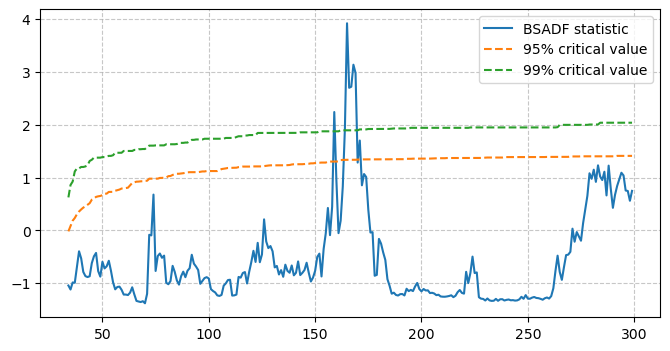

In [18]:
# plot the bsadf

# plot bsadf and critical values from the csv files

bsadf_stat = pd.read_csv("P_rw_bubble_bsadf.csv")
bsadf_cv   = pd.read_csv("P_rw_bubble_cv.csv")

t = P.index[-len(bsadf_stat):]

plt.figure(figsize=(8, 4))
plt.plot(t, bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, bsadf_cv["99%"], "--", label="99% critical value")
plt.legend()
plt.grid(True, alpha=0.7, ls="--")
plt.show()

The BSADF results are displayed below, where it is also clear.

And with correct window size starting time (adjusted for the window size starting at 27)

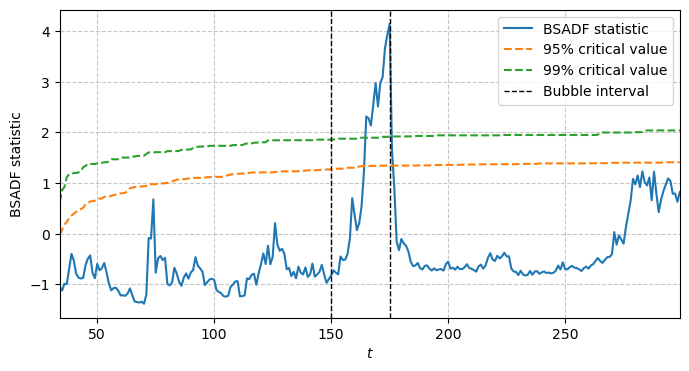

In [51]:
# Load BSADF statistic and critical values for P_rw
P_rw_bubble_bsadf_stat = pd.read_csv("../data/bsadf/P_rw_bubble_bsadf_stat.csv")   # column: "bsadf"
P_rw_bubble_bsadf_cv   = pd.read_csv("../data/bsadf/P_rw_bubble_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

# Load original price series to get T
P_rw_bubble = pd.read_csv("../data/P_rw_bubble.csv")
T = len(P_rw_bubble)

n_bsadf = len(P_rw_bubble_bsadf_stat)
offset = T - n_bsadf            # number of periods at the start with no BSADF
t = np.arange(offset, offset + n_bsadf)   # length matches n_bsadf

plt.figure(figsize=(8, 4))
plt.plot(t, P_rw_bubble_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_rw_bubble_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_rw_bubble_bsadf_cv["99%"], "--", label="99% critical value")
plt.axvline(150, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(175, color="black", linestyle="--", linewidth=1)
plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.savefig("../figures/P_rw_bubble_bsadf.pdf", format="pdf", bbox_inches="tight")
plt.show()

Now we do the same on simulated data where $\rho<1$ on both sides of the bubble to show the test is still working with a bubble. The stationary AR(1) with e.g. $\rho = 0.8$ looks like this:

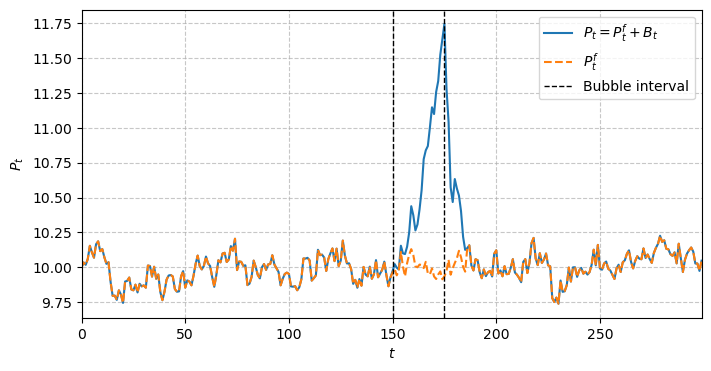

In [55]:
Pf, B, P = simulation_master.simulate_price_with_bubbles(
    T=300,
    P0=10.0,
    sigma_f=0.07,
    mu_f=2.00,
    rho=0.8,              # random walk fundamental
    include_bubble=True,
    R=0.10,
    sigma_b=0.07,
    bubble_decay=0.70,
    t_start1=150,          # first bubble interval
    t_end1=175,
    B0_1=0.01,
    seed=42,
)

plt.figure(figsize=(8, 4))
plt.plot(P, label=r"$P_t = P_t^f + B_t$")
plt.plot(Pf, label=r"$P_t^f$", linestyle="--")
# plt.plot(B, label=r"$B_t$")
plt.xlabel("$t$")
plt.axvline(150, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(175, color="black", linestyle="--", linewidth=1)
plt.ylabel("$P_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.legend()
# save as pdf to figures folder
plt.savefig("../figures/P_stationary_bubble.pdf", format="pdf", bbox_inches="tight")
plt.show()

# Save price series as csv to data folder
P.to_csv("../data/P_stationary_bubble.csv", index=False)

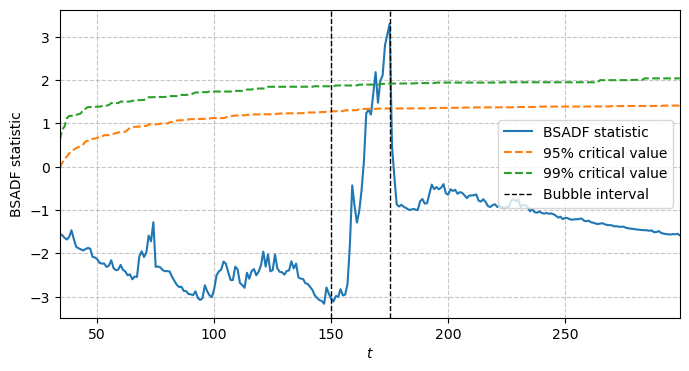

In [58]:
# Load BSADF statistic and critical values for P_rw
P_stationary_bubble_bsadf_stat = pd.read_csv("../data/bsadf/P_stationary_bubble_bsadf_stat.csv")   # column: "bsadf"
P_stationary_bubble_bsadf_cv   = pd.read_csv("../data/bsadf/P_stationary_bubble_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

# Load original price series to get T
P_stationary_bubble = pd.read_csv("../data/P_stationary_bubble.csv")
T = len(P_stationary_bubble)

n_bsadf = len(P_stationary_bubble_bsadf_stat)
offset = T - n_bsadf            # number of periods at the start with no BSADF
t = np.arange(offset, offset + n_bsadf)   # length matches n_bsadf

plt.figure(figsize=(8, 4))
plt.plot(t, P_stationary_bubble_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_stationary_bubble_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_stationary_bubble_bsadf_cv["99%"], "--", label="99% critical value")
plt.axvline(150, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(175, color="black", linestyle="--", linewidth=1)
plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.savefig("../figures/P_stationary_bubble_bsadf.pdf", format="pdf", bbox_inches="tight")
plt.show()

Now we want to show 2 bubbles and different values of $\rho$ over the samplem to show the procedure is still detecting explosive bubbles, and including a trend to mimic steady, normal growth. 

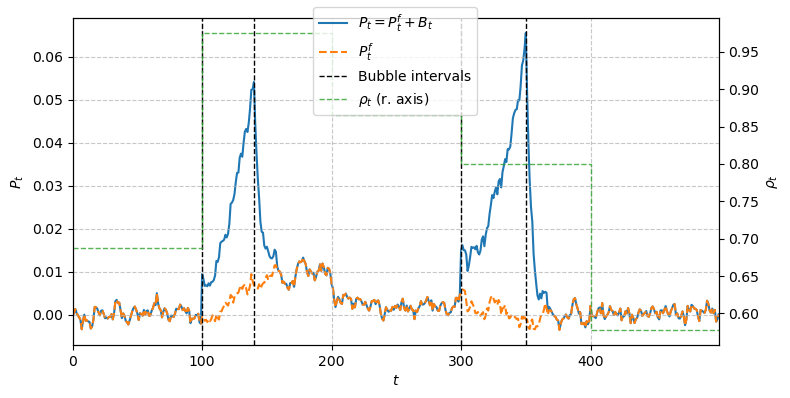

In [122]:
T = 500
Pf_tv, B_tv, P_tv, rho_tv = simulation_master.simulate_price_with_bubbles(
    T=T,
    random_rho=True,
    return_rho=True,
    rho_min=0.5,
    rho_max=1.0,
    rho_block_size=100,
    P0=0.0,
    mu_f=0.0001,
    sigma_f=0.001,
    include_bubble=True,
    R=0.04,
    sigma_b=0.001,
    t_start1=100,
    t_end1=140,
    B0_1=0.01,
    t_start2=300,
    t_end2=350,
    B0_2=0.01,
    bubble_decay=0.8,
    seed=42,
)

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left axis: price
ax1.plot(P_tv.index, P_tv.values, label=r"$P_t = P_t^f + B_t$", color="tab:blue", zorder=1)
ax1.plot(Pf_tv.index, Pf_tv.values, label=r"$P_t^f$", color="tab:orange", zorder=1, linestyle = "--")
ax1.set_xlabel("$t$")
ax1.set_ylabel(r"$P_t$")
ax1.tick_params(axis="y")
ax1.axvline(100, color="black", linestyle="--", label="Bubble intervals", linewidth=1)
ax1.axvline(140, color="black", linestyle="--", linewidth=1)
ax1.axvline(300, color="black", linestyle="--", linewidth=1)
ax1.axvline(350, color="black", linestyle="--", linewidth=1) 
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.margins(x=0)

# Right axis: rho_t
ax2 = ax1.twinx()
ax2.step(rho_tv.index, rho_tv.values, where="post", color="tab:green", label=r"$\rho_t$ (r. axis)", zorder=0, linestyle="--", alpha=0.8, linewidth=1)
ax2.set_ylabel(r"$\rho_t$")
ax2.tick_params(axis="y")
ax2.set_zorder(0)


fig.legend(loc="upper center")
fig.tight_layout()

plt.savefig("../figures/P_tv.pdf", format="pdf", bbox_inches="tight")

plt.show()

# download as csv
P_tv.to_csv("../data/P_tv.csv", index=False)

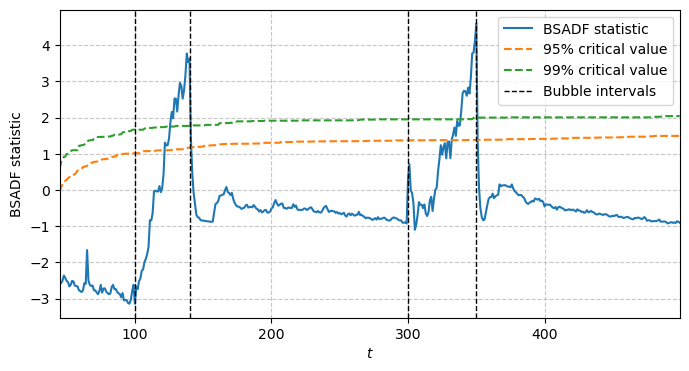

In [125]:
# Load BSADF statistic and critical values for P_rw
P_tv_bsadf_stat = pd.read_csv("../data/bsadf/P_tv_bsadf_stat.csv")   # column: "bsadf"
P_tv_bsadf_cv   = pd.read_csv("../data/bsadf/P_tv_bsadf_cv.csv")     # columns: "90%", "95%", "99%"

# Load original price series to get T
P_tv = pd.read_csv("../data/P_tv.csv")
T = len(P_tv)

n_bsadf = len(P_tv_bsadf_stat)
offset = T - n_bsadf            # number of periods at the start with no BSADF
t = np.arange(offset, offset + n_bsadf)   # length matches n_bsadf

plt.figure(figsize=(8, 4))
plt.plot(t, P_tv_bsadf_stat["bsadf"], label="BSADF statistic")
plt.plot(t, P_tv_bsadf_cv["95%"], "--", label="95% critical value")
plt.plot(t, P_tv_bsadf_cv["99%"], "--", label="99% critical value")
plt.axvline(100, color="black", linestyle="--", label="Bubble intervals", linewidth=1)
plt.axvline(140, color="black", linestyle="--", linewidth=1)
plt.axvline(300, color="black", linestyle="--", linewidth=1)
plt.axvline(350, color="black", linestyle="--", linewidth=1)
plt.xlabel("$t$")
plt.ylabel("BSADF statistic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.savefig("../figures/P_tv_bsadf.pdf", format="pdf", bbox_inches="tight")
plt.show()

## 2 bobler andre parametre

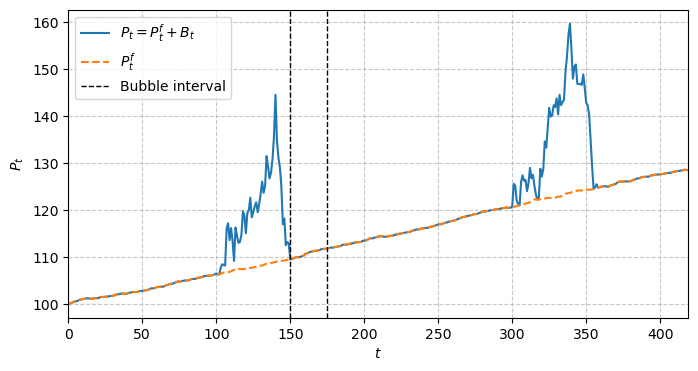

In [32]:
T = 420
Pf, B, P = simulation_master_v1.simulate_price_with_bubbles(
    T=T,
    P0=100,
    mu_f=0.07,
    sigma_f=0.07,
    include_bubble=True,
    R=0.005,
    sigma_b=0.16,
    t_start1=100,
    t_end1=140,
    B0_1=0.01,
    t_start2=300,
    t_end2=350,
    B0_2=0.01,
    bubble_decay=0.8,
    seed=42,
)


plt.figure(figsize=(8, 4))
plt.plot(P, label=r"$P_t = P_t^f + B_t$")
plt.plot(Pf, label=r"$P_t^f$", linestyle="--")
# plt.plot(B, label=r"$B_t$")
plt.xlabel("$t$")
plt.axvline(150, color="black", linestyle="--", label="Bubble interval", linewidth=1)
plt.axvline(175, color="black", linestyle="--", linewidth=1)
plt.ylabel("$P_t$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.margins(x=0)
plt.legend()
plt.show()